# StackScope — analysis walkthrough

This notebook explains the analytical decisions behind the StackScope dashboard, with the evidence for each one.
It reads the DuckDB warehouse produced by `make pipeline` (read-only).

1. How messy is the raw data?
2. Why composition weighting matters
3. Separating signal from noise: significance and false discoveries
4. Cleaning pay without trimming real earners
5. Why controls matter for skill premiums
6. Is the salary model honest about its uncertainty?
7. The GenAI adoption–trust gap

In [1]:
import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from stackscope import settings

con = duckdb.connect(str(settings.WAREHOUSE_PATH), read_only=True)
q = lambda sql: con.execute(sql).df()

INK, BLUE, ORANGE, GRAY = "#0f2a33", "#2a78d6", "#eb6834", "#b9c3c2"
plt.rcParams.update({
    "figure.dpi": 110, "figure.figsize": (9, 4), "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#c3c9c6", "axes.labelcolor": INK, "xtick.color": "#48595f", "ytick.color": "#48595f",
    "axes.grid": True, "grid.color": "#e3e7e5", "grid.linewidth": 0.8, "axes.titleweight": "bold", "axes.titlesize": 12,
    "axes.titlelocation": "left", "font.size": 10,
})
q("SELECT schema_name, count(*) AS tables, sum(estimated_size) AS rows FROM duckdb_tables() GROUP BY 1 ORDER BY 1")

,schema_name,tables,rows
0,core,12,21238615.0
1,dq,6,3043.0
2,mart,34,56687.0
3,ml,3,98.0


## 1. How messy is the raw data?

Nine annual files, each with its own schema. The same technology appears under different labels and even in different
questions from year to year, so every share needs the right denominator for its year.

In [2]:
coverage = q("""SELECT survey_year, count(DISTINCT raw_label) AS raw_labels, sum(mentions) AS mentions,
                     round(100 * sum(mentions) FILTER (WHERE status = 'mapped') / sum(mentions) FILTER (WHERE status <> 'excluded'), 2) AS pct_mapped
              FROM dq.label_coverage GROUP BY 1 ORDER BY 1""")
aliases = q("""SELECT tech, list(DISTINCT raw_label) AS raw_labels FROM dq.label_coverage
              WHERE status = 'mapped' GROUP BY tech HAVING count(DISTINCT raw_label) >= 3 ORDER BY count(DISTINCT raw_label) DESC LIMIT 8""")
display(coverage)
aliases

,survey_year,raw_labels,mentions,pct_mapped
0,2017,89,713885.0,100.0
1,2018,119,2113738.0,100.0
2,2019,109,2663660.0,100.0
3,2020,90,1599356.0,100.0
4,2021,125,2636105.0,100.0
5,2022,161,2384236.0,100.0
6,2023,291,3641157.0,100.0
7,2024,279,2516216.0,100.0
8,2025,185,1175747.0,100.0


,tech,raw_labels
0,.NET,"[.NET Framework, .NET, .NET Core / .NET 5, .NE..."
1,ChatGPT / OpenAI,"[ChatGPT, openAI Image generating models, Open..."
2,Google Gemini,"[Google Bard AI, Gemini (Pro Reasoning models)..."
3,Angular,"[AngularJS, Angular.js, Angular/Angular.js, An..."
4,Jupyter,"[Jupyter Notebook/JupyterLab, IPython / Jupyte..."
5,Spring,"[Spring, Spring Framework, Spring Boot]"
6,ASP.NET,"[ASP.NET, ASP.NET CORE, ASP.NET Core]"
7,Google Cloud,"[Google Cloud Platform/App Engine, Google Clou..."


## 2. Why composition weighting matters

The survey's respondent mix shifts between waves (for example the share of learners and of respondents from South Asia).
A raw year-over-year change mixes real technology shifts with *who answered*. Each wave is raked to the same reference
composition; below, the raw and weighted shares of the respondent mix and one technology.

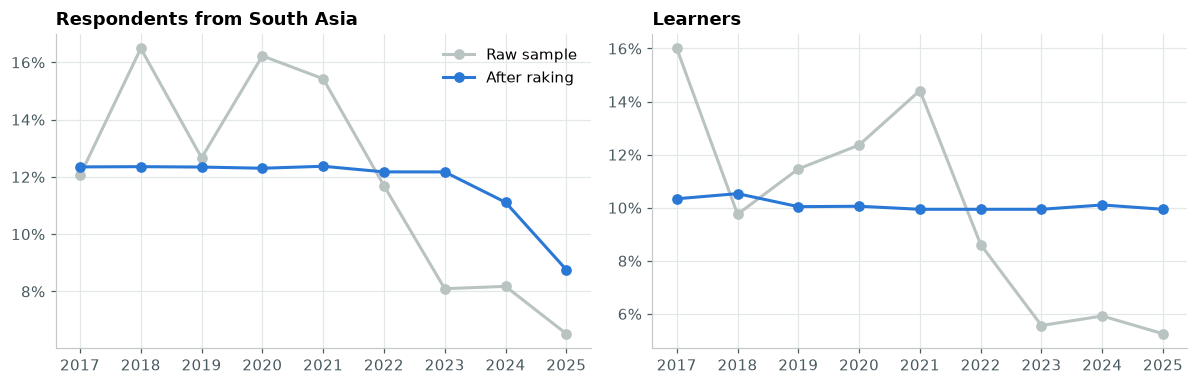

,survey_year,design_effect,effective_n
0,2017,1.0768,47727
1,2018,1.2203,81010
2,2019,1.0254,86685
3,2020,1.0399,61986
4,2021,1.0624,78539
5,2022,1.0241,71546
6,2023,1.0677,83527
7,2024,1.0707,61116
8,2025,1.1436,42953


In [3]:
mix = q("""SELECT r.survey_year,
                   avg(CASE WHEN r.region = 'South Asia' THEN 1.0 ELSE 0 END) AS raw_south_asia,
                   sum(w.weight * CASE WHEN r.region = 'South Asia' THEN 1 ELSE 0 END) / sum(w.weight) AS weighted_south_asia,
                   avg(CASE WHEN r.respondent_type = 'Learner' THEN 1.0 ELSE 0 END) AS raw_learners,
                   sum(w.weight * CASE WHEN r.respondent_type = 'Learner' THEN 1 ELSE 0 END) / sum(w.weight) AS weighted_learners
            FROM core.fact_respondent r JOIN core.respondent_weight w USING (resp_key) GROUP BY 1 ORDER BY 1""")
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=False)
for ax, key, title in [(axes[0], "south_asia", "Respondents from South Asia"), (axes[1], "learners", "Learners")]:
    ax.plot(mix.survey_year, mix[f"raw_{key}"], color=GRAY, lw=2, marker="o", label="Raw sample")
    ax.plot(mix.survey_year, mix[f"weighted_{key}"], color=BLUE, lw=2, marker="o", label="After raking")
    ax.set_title(title); ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
axes[0].legend(frameon=False)
plt.tight_layout(); plt.show()
q("SELECT survey_year, design_effect, effective_n FROM dq.weight_diagnostics ORDER BY 1")

## 3. Signal versus noise

With ~950 wave-on-wave comparisons, some will look significant by chance. Benjamini–Hochberg control keeps the expected
share of false discoveries at 5%. With samples this large, though, almost every change clears the bar, so the dashboard
leads with effect sizes (percentage points, annual growth in odds) rather than p-values: practical significance is the
real filter.

In [4]:
yoy = q("SELECT p_value, q_value FROM mart.tech_yoy")
summary = pd.DataFrame({
    "tests": [len(yoy)],
    "p < 0.05 (no correction)": [(yoy.p_value < 0.05).sum()],
    "q < 0.05 (BH-FDR)": [(yoy.q_value < 0.05).sum()],
})
display(summary)
q("""SELECT tech, category, first_year, round(100 * share_first, 1) AS first_pct, round(100 * share_last, 1) AS latest_pct,
          round(100 * odds_growth, 1) AS odds_growth_pct_per_year, trend
   FROM mart.tech_trend WHERE trend IN ('Rising', 'Declining') AND n_points >= 7 ORDER BY odds_growth DESC""")

,tests,p < 0.05 (no correction),q < 0.05 (BH-FDR)
0,953,745,733


,tech,category,first_year,first_pct,latest_pct,odds_growth_pct_per_year,trend
0,Visual Studio Code,ide,2017,19.5,77.5,37.5,Rising
1,Rust,language,2017,1.1,15.2,33.8,Rising
2,PyTorch,library,2018,1.7,12.7,32.7,Rising
3,TypeScript,language,2017,10.0,44.3,22.4,Rising
4,React,webframe,2017,19.6,48.4,15.3,Rising
5,PostgreSQL,database,2017,26.9,56.6,14.4,Rising
6,Go,language,2017,4.4,16.4,14.3,Rising
7,Jupyter,ide,2017,5.2,14.8,13.6,Rising
8,Python,language,2017,30.9,59.2,11.4,Rising
9,Kotlin,language,2018,4.3,10.9,11.1,Rising


## 4. Cleaning pay without trimming real earners

Salaries are compared with the full-time median for the same country and year using a MAD-based modified z-score on the
log scale (Iglewicz & Hoaglin, threshold 3.5). This removes monthly-as-annual entries and typos but keeps genuine top
earners in high-paying markets.

,comp_status,n
0,valid,309178
1,market_outlier,13652
2,out_of_bounds,7273
3,no_reference,177


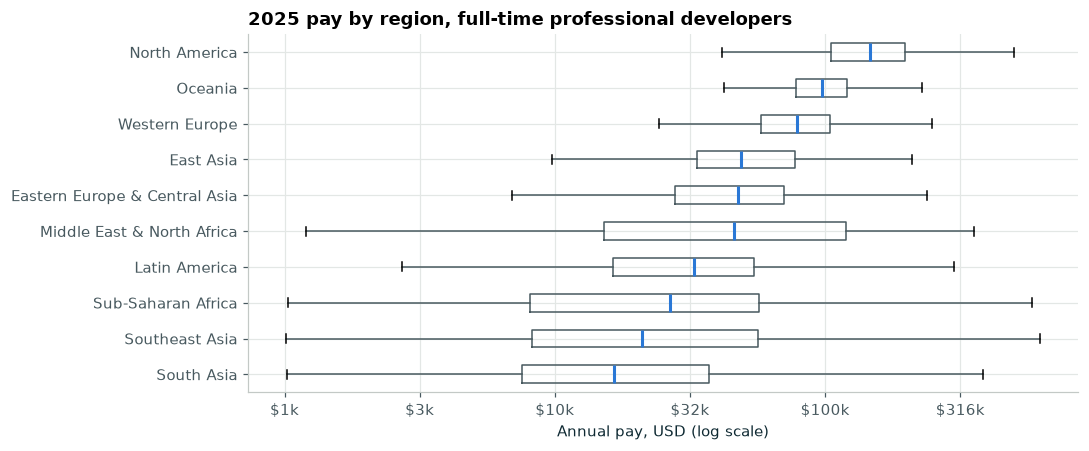

In [5]:
status = q("SELECT comp_status, count(*) AS n FROM core.fact_respondent WHERE comp_usd_raw IS NOT NULL GROUP BY 1 ORDER BY n DESC")
display(status)
pay = q("""SELECT region, comp_usd FROM core.fact_respondent
            WHERE in_pay_benchmark AND survey_year = 2025 AND region IS NOT NULL""")
order = pay.groupby("region").comp_usd.median().sort_values().index
fig, ax = plt.subplots(figsize=(10, 4.2))
ax.boxplot([np.log10(pay.loc[pay.region == r, "comp_usd"]) for r in order], orientation="horizontal", showfliers=False,
           medianprops={"color": BLUE, "lw": 2}, boxprops={"color": "#48595f"}, whiskerprops={"color": "#48595f"})
ax.set_yticklabels(order); ax.set_xlabel("Annual pay, USD (log scale)")
ax.xaxis.set_major_formatter(lambda v, _: f"${10 ** v / 1000:,.0f}k")
ax.set_title("2025 pay by region, full-time professional developers")
plt.tight_layout(); plt.show()

## 5. Why controls matter for skill premiums

The raw pay gap between users and non-users of a technology is dominated by *where* and *how senior* its users are.
The regression holds country, experience, role, company size, education, industry, work arrangement and year constant.

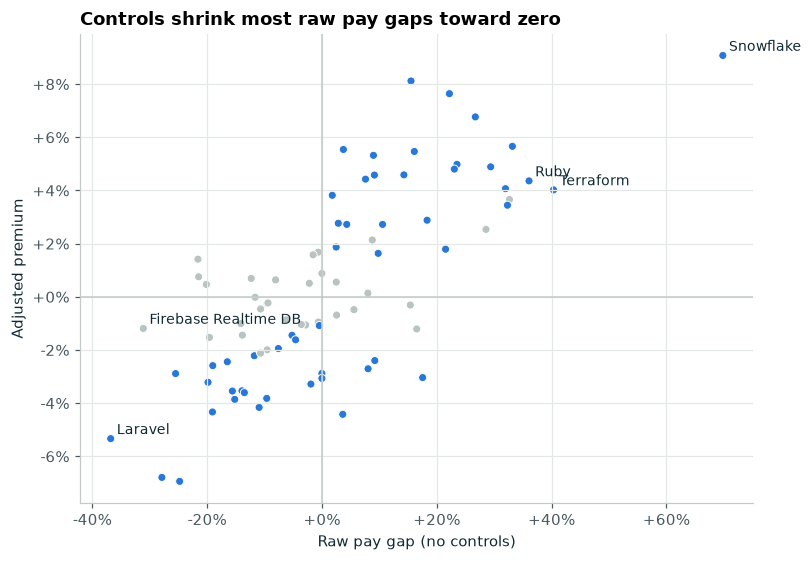

Correlation raw vs adjusted: 0.74; median |raw| 11.7% vs median |adjusted| 2.6%


In [6]:
prem = q("SELECT tech, premium, raw_premium, significant FROM mart.skill_premium WHERE scope = 'Global'")
fig, ax = plt.subplots(figsize=(7.5, 5.2))
ax.axhline(0, color="#c3c9c6", lw=1); ax.axvline(0, color="#c3c9c6", lw=1)
ax.scatter(prem.raw_premium, prem.premium, s=28, color=np.where(prem.significant, BLUE, GRAY), edgecolor="white", lw=0.6)
for _, r in prem.sort_values("raw_premium").iloc[[0, 1, -1, -2, -3]].iterrows():
    ax.annotate(r.tech, (r.raw_premium, r.premium), xytext=(4, 3), textcoords="offset points", fontsize=9, color=INK)
ax.set_xlabel("Raw pay gap (no controls)"); ax.set_ylabel("Adjusted premium")
ax.xaxis.set_major_formatter(lambda v, _: f"{v:+.0%}"); ax.yaxis.set_major_formatter(lambda v, _: f"{v:+.0%}")
ax.set_title("Controls shrink most raw pay gaps toward zero")
plt.tight_layout(); plt.show()
print(f"Correlation raw vs adjusted: {prem[['raw_premium', 'premium']].corr().iloc[0, 1]:.2f}; "
      f"median |raw| {prem.raw_premium.abs().median():.1%} vs median |adjusted| {prem.premium.abs().median():.1%}")

## 6. Is the salary model honest about its uncertainty?

Quantile gradient boosting gives a P10–P90 range; conformalized quantile regression widens it just enough to guarantee
the stated coverage on new data.

,metric,value
0,n_train,46356.0000
1,n_valid,7131.0000
2,n_calib,7131.0000
3,n_test,10700.0000
4,r2_log,0.7293
5,r2_log_baseline,0.5695
6,mae_log,0.3129
7,mae_log_baseline,0.4361
8,median_ape,0.2050
9,median_ape_baseline,0.3043


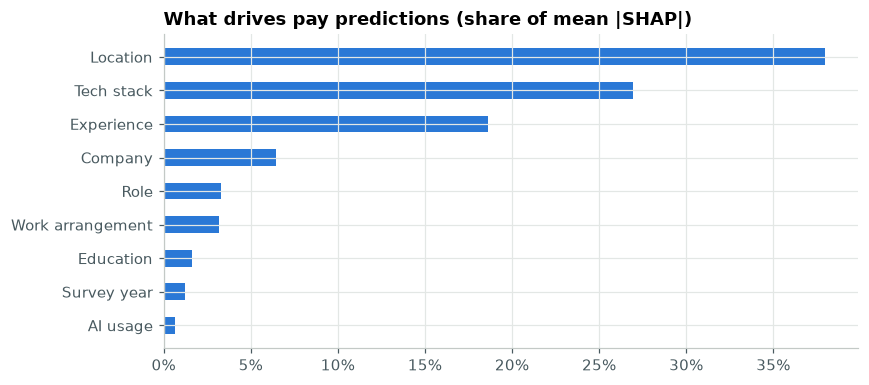

In [7]:
metrics = q("SELECT metric, round(value, 4) AS value FROM ml.salary_model_metrics")
display(metrics)
imp = q("SELECT \"group\", share FROM ml.salary_group_importance ORDER BY share")
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.barh(imp["group"], imp.share, color=BLUE, height=0.5)
ax.xaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.set_title("What drives pay predictions (share of mean |SHAP|)")
plt.tight_layout(); plt.show()

## 7. The GenAI adoption–trust gap

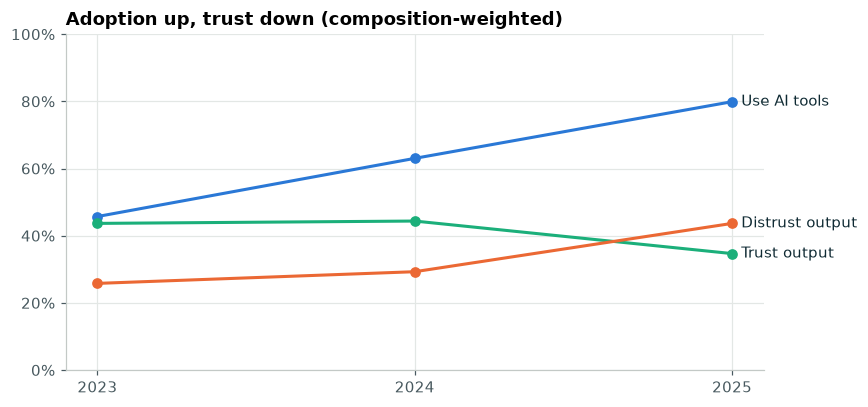

,variable,level,odds_ratio,lo,hi
0,age_band,65+,2.48,1.94,3.17
1,age_band,55-64,2.18,1.88,2.52
2,age_band,45-54,1.75,1.56,1.95
3,age_band,35-44,1.36,1.26,1.47
4,age_band,Unknown,0.72,0.45,1.14
5,age_band,18-24,0.65,0.59,0.71
6,exp_band,0-2,1.88,1.60,2.22
7,exp_band,Unknown,1.40,1.09,1.80
8,exp_band,3-5,1.37,1.24,1.51
9,exp_band,11-20,0.81,0.75,0.87


In [8]:
ai = q("SELECT survey_year, using_w, trust_w, distrust_w FROM mart.ai_year ORDER BY 1")
fig, ax = plt.subplots(figsize=(8, 3.8))
for col, color, label in [("using_w", BLUE, "Use AI tools"), ("trust_w", "#1baf7a", "Trust output"), ("distrust_w", ORANGE, "Distrust output")]:
    ax.plot(ai.survey_year, ai[col], color=color, lw=2, marker="o")
    ax.annotate(label, (ai.survey_year.iloc[-1], ai[col].iloc[-1]), xytext=(6, 0), textcoords="offset points", va="center", color=INK)
ax.set_xticks(ai.survey_year); ax.set_ylim(0, 1); ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.set_title("Adoption up, trust down (composition-weighted)")
plt.tight_layout(); plt.show()
q("SELECT variable, level, round(odds_ratio, 2) AS odds_ratio, round(or_lo, 2) AS lo, round(or_hi, 2) AS hi FROM mart.ai_drivers "
  "WHERE model LIKE 'Trusts%' AND variable IN ('exp_band', 'age_band') ORDER BY variable, odds_ratio DESC")

## Takeaways (computed from the warehouse)

In [9]:
share_sig = (yoy.q_value < 0.05).mean()
shrink = prem.raw_premium.abs().median() / prem.premium.abs().median()
deff = q("SELECT max(design_effect) AS d FROM dq.weight_diagnostics").d.iloc[0]
cov = metrics.set_index("metric").value
print(f"- Harmonisation: even the lowest-coverage wave maps {coverage.pct_mapped.min():.2f}% of in-scope technology mentions.")
print(f"- Weighting corrects composition drift at a small precision cost (largest design effect {deff:.2f}).")
print(f"- {share_sig:.0%} of wave-on-wave changes are significant after FDR control, so effect sizes do the filtering.")
print(f"- Controls shrink the typical technology pay gap {shrink:.1f}x (median raw vs adjusted).")
print(f"- The salary model's calibrated 80% ranges covered {cov['coverage_conformal']:.1%} of unseen salaries "
      f"(vs {cov['coverage_raw']:.1%} before conformal calibration).")

- Harmonisation: even the lowest-coverage wave maps 100.00% of in-scope technology mentions.
- Weighting corrects composition drift at a small precision cost (largest design effect 1.22).
- 77% of wave-on-wave changes are significant after FDR control, so effect sizes do the filtering.
- Controls shrink the typical technology pay gap 4.4x (median raw vs adjusted).
- The salary model's calibrated 80% ranges covered 79.5% of unseen salaries (vs 74.7% before conformal calibration).
